# Class 07 — Meta-Analysis and Publication Bias
**DSC 215 · Statistical Critical Thinking & Experimental Design · UCSD**

*Based on lecture slides by Armin Schwartzman, DSC 215 — Spring 2026*

---

When multiple independent groups study the same phenomenon, their estimates disagree due to sampling variability and different sample sizes. A simple average treats all studies equally — but a study of $n = 10$ should not carry the same weight as one of $n = 10{,}000$. The **inverse-variance weighted estimator** is the correct combination. The **funnel plot** then diagnoses whether the set of published studies is a representative sample of all studies that were run, or whether small null-result studies are missing — the signature of **publication bias**.

**Contents:**
1. [Setup & Imports](#1)
2. [Why Simple Averaging Fails](#2)
3. [The Inverse-Variance Weighted Estimator](#3)
4. [The Simple Model — Exponential Sample Sizes](#4)
5. [The Funnel Plot — Deriving the Boundary Lines](#5)
6. [Publication Bias in the Funnel Plot](#6)
7. [Egger's Test — Formal Asymmetry Test](#7)
8. [Summary & Corollaries](#8)

---

<a id='1'></a>
## 1. Setup & Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import os

np.random.seed(42)
os.makedirs('figures', exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

BLUE   = '#2563EB'
RED    = '#DC2626'
GREEN  = '#16A34A'
ORANGE = '#D97706'
GRAY   = '#6B7280'
PURPLE = '#7C3AED'

print('Ready.')

Ready.


<a id='2'></a>
## 2. Why Simple Averaging Fails

Suppose $J$ studies each estimate the same effect $\mu$. The naive approach is a simple (unweighted) average:

$$\hat{\mu}_{\text{simple}} = \frac{1}{J} \sum_{j=1}^{J} \hat{\mu}_j$$

This is wrong because it gives equal weight to a study with $n = 10$ and one with $n = 10{,}000$. The small study has a much larger variance and contributes mostly noise. The simple average has variance:

$$\text{Var}(\hat{\mu}_{\text{simple}}) = \frac{1}{J^2} \sum_{j=1}^{J} \frac{1}{n_j}$$

Below we demonstrate concretely how the simple average is dominated by the noisiest studies.

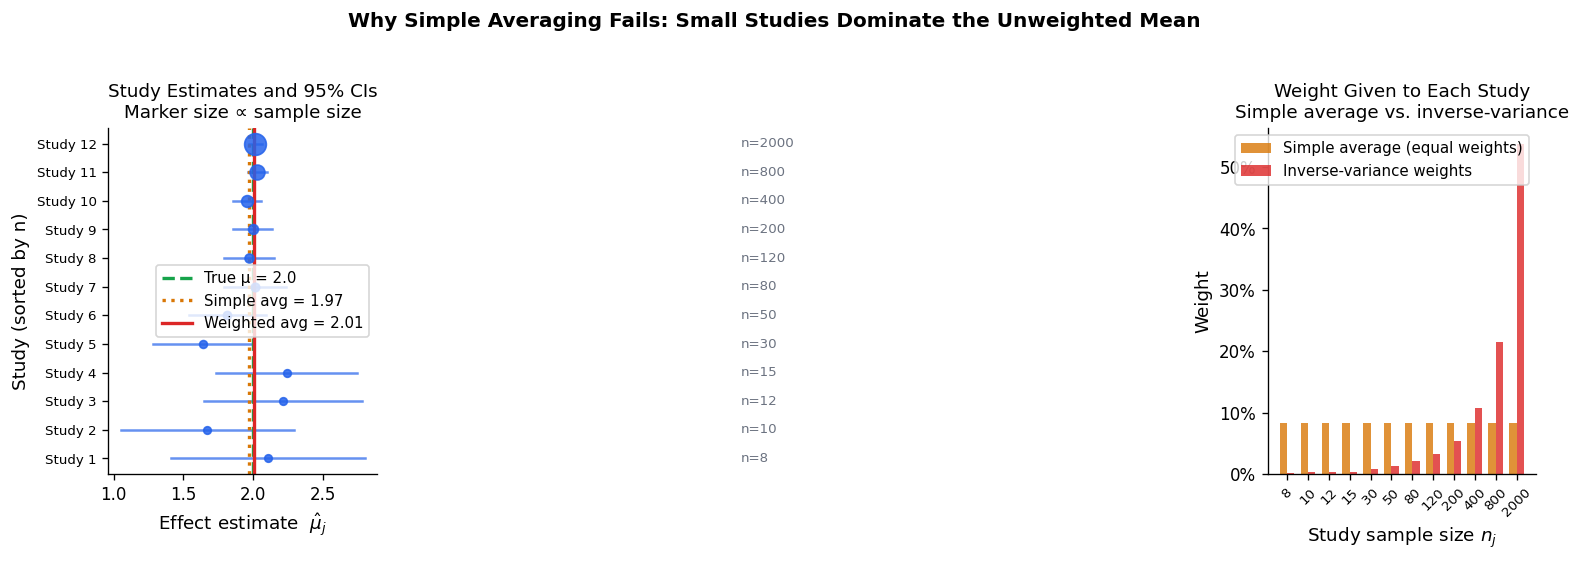

✓ Saved: figures/01_simple_vs_weighted.png

True μ:              2.000
Simple average:      1.974  (error = -0.026)
Weighted average:    2.006  (error = +0.006)


In [3]:
rng     = np.random.default_rng(42)
mu_true = 2.0
J       = 12

# Heterogeneous sample sizes: mix of small and large studies
n_j    = np.array([8, 10, 12, 15, 30, 50, 80, 120, 200, 400, 800, 2000])
se_j   = 1.0 / np.sqrt(n_j)          # sigma_j = 1 for all j (slide assumption)
mu_hat = rng.normal(loc=mu_true, scale=se_j)

mu_simple   = mu_hat.mean()
weights_iv  = n_j                     # w_j = n_j / sigma^2 = n_j when sigma=1
mu_weighted = np.average(mu_hat, weights=weights_iv)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: estimates with CIs, sorted by n
ax = axes[0]
y  = np.arange(J)
for i, (y_i, est, se, n) in enumerate(zip(y, mu_hat, se_j, n_j)):
    ax.plot([est - 1.96*se, est + 1.96*se], [y_i, y_i],
            color=BLUE, lw=1.5, alpha=0.7)
    ax.scatter(est, y_i, s=20 + 150 * n / n_j.max(),
               color=BLUE, zorder=4, alpha=0.85)
    ax.text(mu_true + 3.5, y_i, f'n={n}', va='center', fontsize=8, color=GRAY)

ax.axvline(mu_true,    color=GREEN,  ls='--', lw=2,   label=f'True μ = {mu_true}')
ax.axvline(mu_simple,  color=ORANGE, ls=':',  lw=2,   label=f'Simple avg = {mu_simple:.2f}')
ax.axvline(mu_weighted,color=RED,    ls='-',  lw=2,   label=f'Weighted avg = {mu_weighted:.2f}')
ax.set_xlabel('Effect estimate  $\\hat{\\mu}_j$')
ax.set_ylabel('Study (sorted by n)')
ax.set_yticks(y)
ax.set_yticklabels([f'Study {i+1}' for i in range(J)], fontsize=8)
ax.set_title('Study Estimates and 95% CIs\nMarker size ∝ sample size', fontsize=11)
ax.legend(fontsize=9)

# Right: contribution of each study to each average
ax2 = axes[1]
simple_w  = np.ones(J) / J
iv_w      = weights_iv / weights_iv.sum()
x         = np.arange(J)
width     = 0.35
ax2.bar(x - width/2, simple_w,  width, color=ORANGE, alpha=0.8, label='Simple average (equal weights)')
ax2.bar(x + width/2, iv_w,      width, color=RED,    alpha=0.8, label='Inverse-variance weights')
ax2.set_xticks(x)
ax2.set_xticklabels([f'{n}' for n in n_j], fontsize=8, rotation=45)
ax2.set_xlabel('Study sample size $n_j$')
ax2.set_ylabel('Weight')
ax2.set_title('Weight Given to Each Study\nSimple average vs. inverse-variance', fontsize=11)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.legend(fontsize=9)

plt.suptitle(
    'Why Simple Averaging Fails: Small Studies Dominate the Unweighted Mean',
    fontsize=12, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.savefig('figures/01_simple_vs_weighted.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/01_simple_vs_weighted.png')
print(f'\nTrue μ:              {mu_true:.3f}')
print(f'Simple average:      {mu_simple:.3f}  (error = {mu_simple - mu_true:+.3f})')
print(f'Weighted average:    {mu_weighted:.3f}  (error = {mu_weighted - mu_true:+.3f})')

<a id='3'></a>
## 3. The Inverse-Variance Weighted Estimator

The correct pooled estimate weights each study inversely proportional to its variance:

$$\hat{\mu} = \frac{\displaystyle\sum_{j=1}^{J} \hat{\mu}_j \cdot n_j/\hat{\sigma}_j^2}{\displaystyle\sum_{j=1}^{J} n_j/\hat{\sigma}_j^2}$$

Under the simplifying assumption $\sigma_j = 1$, this reduces to weighting by $n_j$ directly. The standard error of the pooled estimate is:

$$\text{SE}(\hat{\mu}) = \frac{1}{\sqrt{\sum_{j=1}^{J} n_j/\hat{\sigma}_j^2}}$$

We verify this via repeated simulation: the weighted estimator is consistently closer to $\mu$ than the simple average, and its variance matches the theoretical prediction.

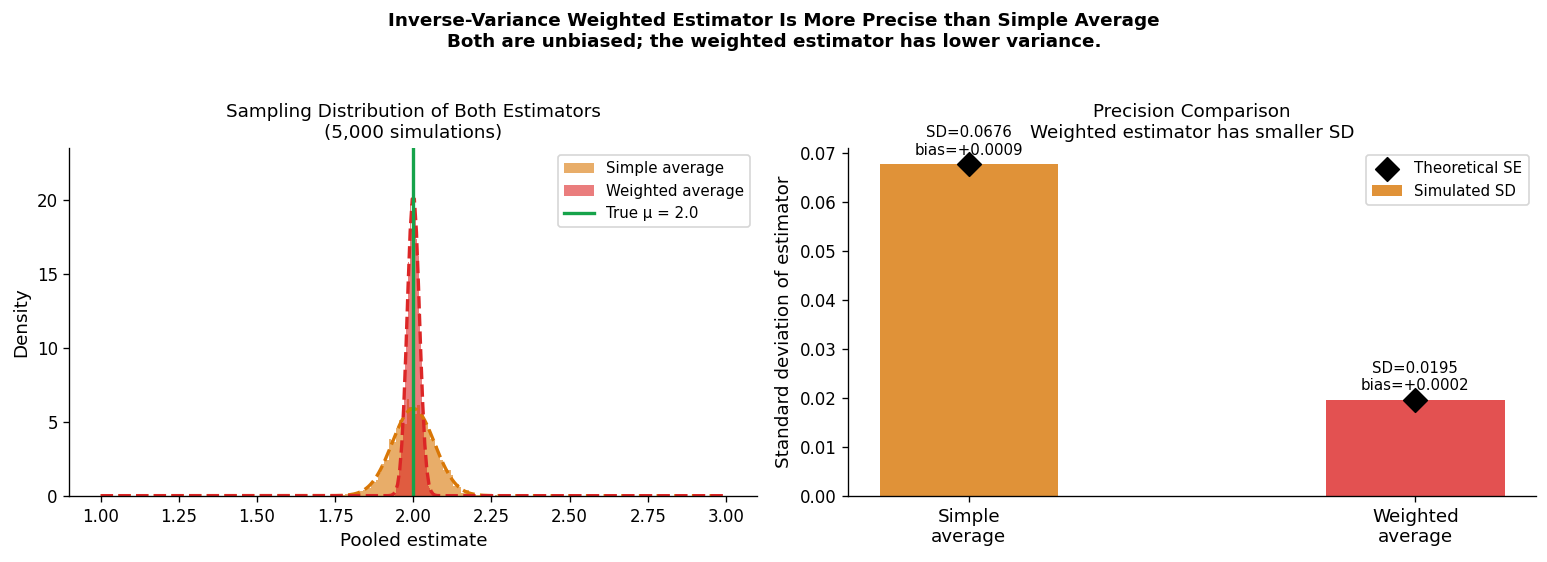

✓ Saved: figures/02_iv_estimator.png

Simple average   — bias: +0.0009,  SD: 0.0676,  theory SE: 0.0676
Weighted average — bias: +0.0002,  SD: 0.0195,  theory SE: 0.0196
Variance ratio (simple / weighted): 12.02× — weighted is more precise


In [4]:
def meta_weighted(mu_hats, n_j, sigma_j=None):
    """Inverse-variance weighted pooled estimate and SE.
    Assumes sigma_j = 1 for all j if sigma_j is None.
    """
    if sigma_j is None:
        sigma_j = np.ones_like(n_j, dtype=float)
    weights   = n_j / sigma_j**2
    mu_pool   = np.sum(mu_hats * weights) / weights.sum()
    se_pool   = 1.0 / np.sqrt(weights.sum())
    return mu_pool, se_pool

# Simulation: repeat 5000 times and compare both estimators
rng      = np.random.default_rng(0)
n_sims   = 5000
mu_true  = 2.0
n_j_sim  = np.array([10, 30, 50, 120, 400, 2000])
se_j_sim = 1.0 / np.sqrt(n_j_sim)

simple_ests   = []
weighted_ests = []

for _ in range(n_sims):
    mu_hat = rng.normal(loc=mu_true, scale=se_j_sim)
    simple_ests.append(mu_hat.mean())
    w_est, _ = meta_weighted(mu_hat, n_j_sim)
    weighted_ests.append(w_est)

simple_ests   = np.array(simple_ests)
weighted_ests = np.array(weighted_ests)

# Theoretical SE for each estimator
se_simple_theory   = np.sqrt((se_j_sim**2).mean() / len(n_j_sim))
_, se_pool_theory  = meta_weighted(np.zeros(len(n_j_sim)), n_j_sim)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

x_range = np.linspace(1.0, 3.0, 300)

ax = axes[0]
ax.hist(simple_ests,   bins=60, color=ORANGE, alpha=0.6, density=True, label='Simple average')
ax.hist(weighted_ests, bins=60, color=RED,    alpha=0.6, density=True, label='Weighted average')
ax.plot(x_range, stats.norm.pdf(x_range, mu_true, se_simple_theory),
        color=ORANGE, lw=2, ls='--')
ax.plot(x_range, stats.norm.pdf(x_range, mu_true, se_pool_theory),
        color=RED,    lw=2, ls='--')
ax.axvline(mu_true, color=GREEN, lw=2, ls='-', label=f'True μ = {mu_true}')
ax.set_xlabel('Pooled estimate')
ax.set_ylabel('Density')
ax.set_title(f'Sampling Distribution of Both Estimators\n({n_sims:,} simulations)', fontsize=11)
ax.legend(fontsize=9)

ax2 = axes[1]
labels  = ['Simple\naverage', 'Weighted\naverage']
biases  = [simple_ests.mean() - mu_true, weighted_ests.mean() - mu_true]
std_sim = [simple_ests.std(),            weighted_ests.std()]
std_th  = [se_simple_theory,             se_pool_theory]

x = np.array([0, 1])
ax2.bar(x, std_sim, color=[ORANGE, RED], alpha=0.8, width=0.4, label='Simulated SD')
ax2.scatter(x, std_th, color='black', s=100, zorder=5, marker='D', label='Theoretical SE')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=11)
ax2.set_ylabel('Standard deviation of estimator')
ax2.set_title('Precision Comparison\nWeighted estimator has smaller SD', fontsize=11)
ax2.legend(fontsize=9)
for i, (s, b) in enumerate(zip(std_sim, biases)):
    ax2.text(i, s + 0.002, f'SD={s:.4f}\nbias={b:+.4f}', ha='center', fontsize=9)

plt.suptitle(
    'Inverse-Variance Weighted Estimator Is More Precise than Simple Average\n'
    'Both are unbiased; the weighted estimator has lower variance.',
    fontsize=11, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.savefig('figures/02_iv_estimator.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/02_iv_estimator.png')
print(f'\nSimple average   — bias: {biases[0]:+.4f},  SD: {std_sim[0]:.4f},  theory SE: {std_th[0]:.4f}')
print(f'Weighted average — bias: {biases[1]:+.4f},  SD: {std_sim[1]:.4f},  theory SE: {std_th[1]:.4f}')
print(f'Variance ratio (simple / weighted): {(std_sim[0]/std_sim[1])**2:.2f}× — weighted is more precise')

<a id='4'></a>
## 4. The Simple Model — Exponential Sample Sizes

The slides introduce a tractable model for the distribution of sample sizes across studies. With $\sigma_j = 1$ for all $j$:

$$\hat{\mu}_j \sim N\!\left(\mu,\, \frac{1}{n_j}\right), \qquad j = 1, \ldots, J$$

Sample sizes are assumed to follow an exponential distribution:

$$n \sim \text{Exp}(\lambda) \qquad \Leftrightarrow \qquad \log\!\left(\frac{n}{\lambda}\right) \sim \text{Unif}(0, 1)$$

This means sample sizes are **log-uniformly distributed** — a realistic model for a research literature where studies span a wide range of sizes. Below we verify this model and show how the marginal distribution of $\hat{\mu}$ looks when $n$ is random.

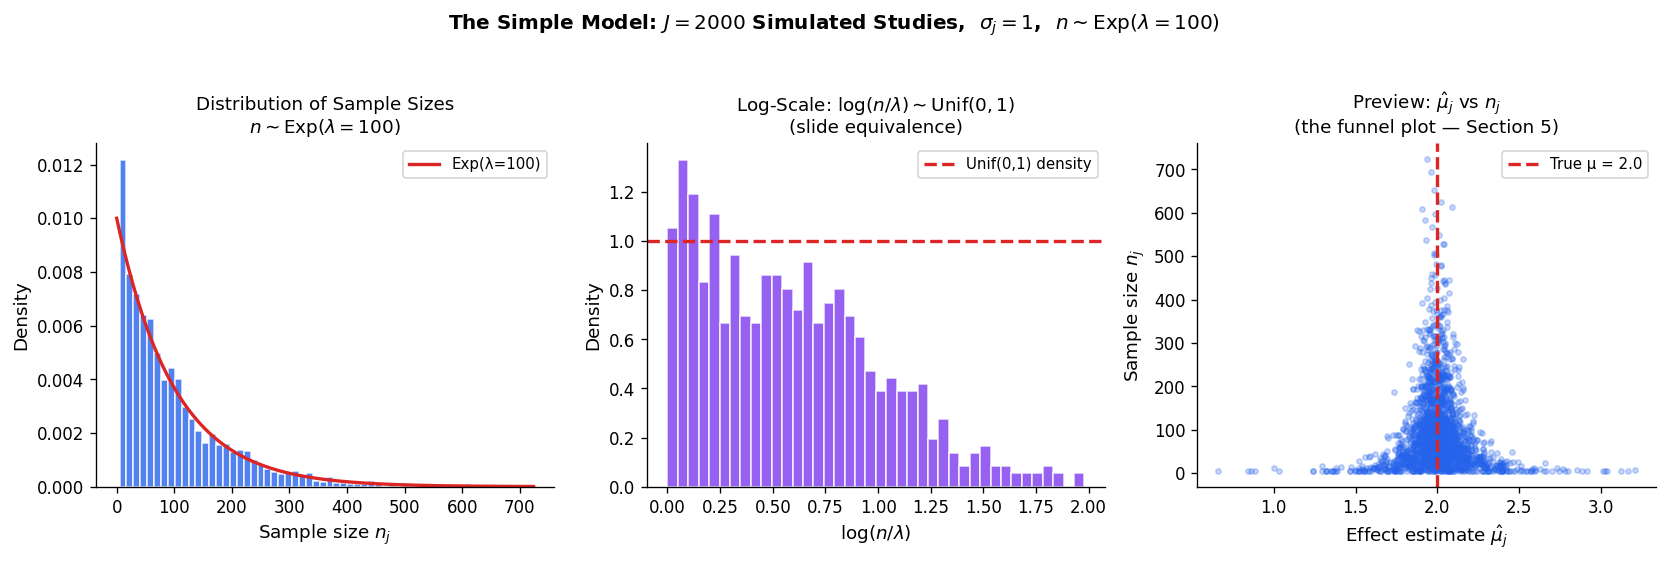

✓ Saved: figures/03_simple_model.png

Sample size summary:
  Mean:   99.4  (theoretical: 100)
  Median: 68.0  (theoretical: 69.3)
  Range:  [5, 724]


In [5]:
rng    = np.random.default_rng(7)
lam    = 100       # mean sample size
J      = 2000      # number of simulated studies
mu_true = 2.0

# Simulate n ~ Exp(lambda)
n_sim   = rng.exponential(scale=lam, size=J).astype(int).clip(min=5)
se_sim  = 1.0 / np.sqrt(n_sim)
mu_sim  = rng.normal(loc=mu_true, scale=se_sim)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Left: distribution of n
ax = axes[0]
ax.hist(n_sim, bins=60, color=BLUE, edgecolor='white', alpha=0.8, density=True)
x_exp = np.linspace(0, n_sim.max(), 300)
ax.plot(x_exp, stats.expon.pdf(x_exp, scale=lam), color=RED, lw=2, label=f'Exp(λ={lam})')
ax.set_xlabel('Sample size $n_j$')
ax.set_ylabel('Density')
ax.set_title(f'Distribution of Sample Sizes\n$n \\sim \\text{{Exp}}(\\lambda={lam})$', fontsize=11)
ax.legend(fontsize=9)

# Middle: distribution of log(n/lambda) — should be Unif(0,1)
ax2 = axes[1]
log_n = np.log(n_sim / lam)
log_n_clipped = log_n[log_n >= 0]   # keep the Unif(0,1) region
ax2.hist(log_n_clipped, bins=40, color=PURPLE, edgecolor='white', alpha=0.8, density=True)
ax2.axhline(1.0, color=RED, lw=2, ls='--', label='Unif(0,1) density')
ax2.set_xlabel('$\\log(n / \\lambda)$')
ax2.set_ylabel('Density')
ax2.set_title('Log-Scale: $\\log(n/\\lambda) \\sim \\text{Unif}(0,1)$\n(slide equivalence)', fontsize=11)
ax2.legend(fontsize=9)

# Right: scatter of mu_hat vs n — this IS the funnel plot (preview)
ax3 = axes[2]
ax3.scatter(mu_sim, n_sim, alpha=0.25, s=10, color=BLUE)
ax3.axvline(mu_true, color=RED, lw=2, ls='--', label=f'True μ = {mu_true}')
ax3.set_xlabel('Effect estimate $\\hat{\\mu}_j$')
ax3.set_ylabel('Sample size $n_j$')
ax3.set_title('Preview: $\\hat{\\mu}_j$ vs $n_j$\n(the funnel plot — Section 5)', fontsize=11)
ax3.legend(fontsize=9)

plt.suptitle(
    f'The Simple Model: $J={J}$ Simulated Studies,  $\\sigma_j=1$,  $n \\sim \\text{{Exp}}(\\lambda={lam})$',
    fontsize=12, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.savefig('figures/03_simple_model.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/03_simple_model.png')
print(f'\nSample size summary:')
print(f'  Mean:   {n_sim.mean():.1f}  (theoretical: {lam})')
print(f'  Median: {np.median(n_sim):.1f}  (theoretical: {lam * np.log(2):.1f})')
print(f'  Range:  [{n_sim.min()}, {n_sim.max()}]')

<a id='5'></a>
## 5. The Funnel Plot — Deriving the Boundary Lines

The **funnel plot** graphs $\hat{\mu}_j$ (horizontal) against $n_j$ (vertical). The boundary lines are placed at **2 standard errors** from the true $\mu$:

$$b = \mu \pm \frac{2}{\sqrt{n}}$$

Inverting, to express $n$ as a function of boundary position $b$:

$$n = \left(\frac{2}{|b - \mu|}\right)^2$$

Taking the log (since $n$ is log-uniformly distributed under the model):

$$\log n = 2\log\!\left(\frac{2}{|b - \mu|}\right)$$

This gives the characteristic funnel shape: wide at the bottom (high variance, small $n$) and narrow at the top (low variance, large $n$). Under the model, ~95% of studies fall inside the funnel.

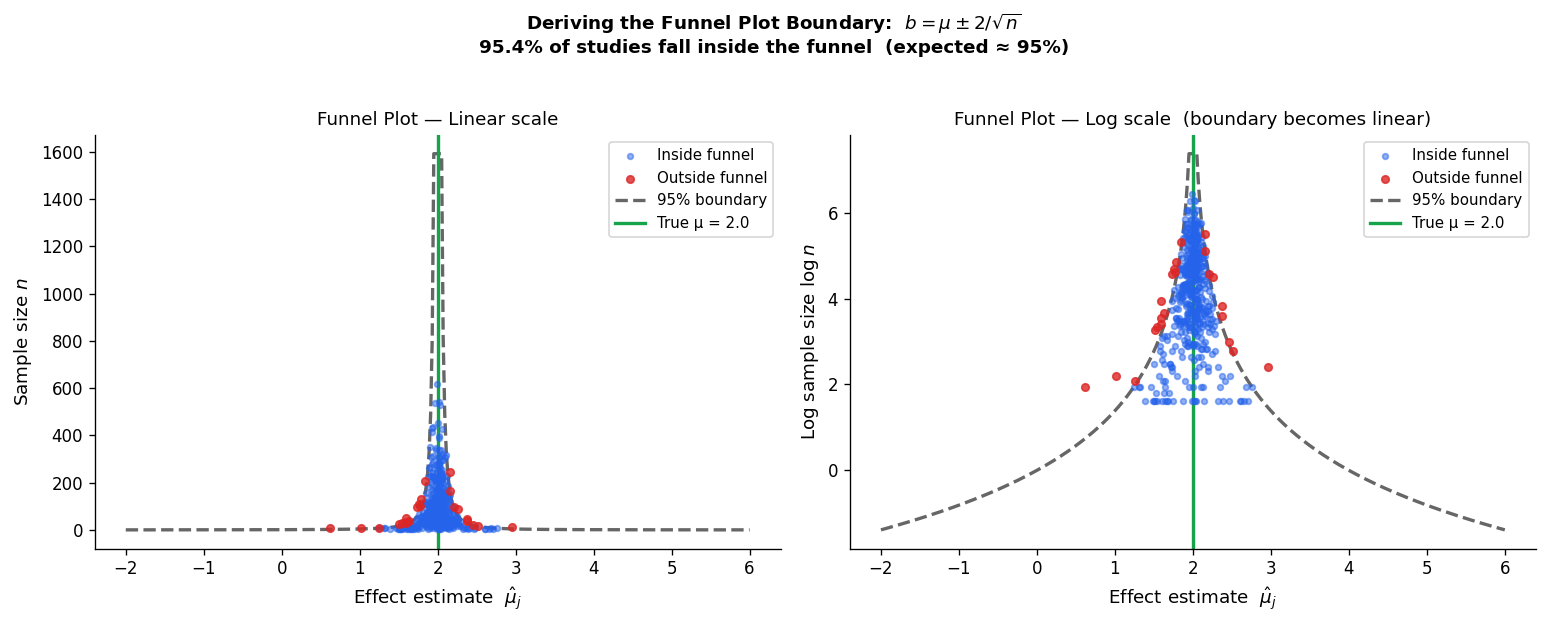

✓ Saved: figures/04_funnel_derivation.png

Boundary formula:
  b = μ ± 2/√n   →   n = (2/|b−μ|)²   →   log n = 2·log(2/|b−μ|)
Studies inside 95% funnel: 477 / 500 = 95.4%


In [6]:
def funnel_boundary_n(b_vals, mu, on_log_scale=False):
    """Compute n on the funnel boundary.
    b_vals : array of effect-size positions on horizontal axis
    mu     : true effect
    Returns n (or log n if on_log_scale=True).
    """
    dist = np.abs(b_vals - mu)
    dist = np.where(dist < 1e-6, 1e-6, dist)   # avoid division by zero
    n_boundary = (2.0 / dist) ** 2
    return np.log(n_boundary) if on_log_scale else n_boundary

rng     = np.random.default_rng(42)
lam     = 100
J       = 500
mu_true = 2.0

n_j   = rng.exponential(scale=lam, size=J).astype(int).clip(min=5)
se_j  = 1.0 / np.sqrt(n_j)
mu_hat = rng.normal(loc=mu_true, scale=se_j)

# Inside funnel: |mu_hat - mu| < 2/sqrt(n)
inside = np.abs(mu_hat - mu_true) < 2.0 / np.sqrt(n_j)

# Boundary curve on n scale and log-n scale
b_range = np.linspace(mu_true - 4, mu_true + 4, 400)
b_range_plot = b_range[np.abs(b_range - mu_true) > 0.05]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, log_scale, ylabel, title_suffix in [
    (axes[0], False, 'Sample size $n$',      'Linear scale'),
    (axes[1], True,  'Log sample size $\\log n$', 'Log scale  (boundary becomes linear)'),
]:
    y_inside  = np.log(n_j) if log_scale else n_j
    y_outside = np.log(n_j[~inside]) if log_scale else n_j[~inside]
    y_in      = np.log(n_j[inside])  if log_scale else n_j[inside]

    ax.scatter(mu_hat[inside],  y_in,      color=BLUE, s=12, alpha=0.5, zorder=3, label='Inside funnel')
    ax.scatter(mu_hat[~inside], y_outside, color=RED,  s=20, alpha=0.8, zorder=4, label='Outside funnel')

    n_bound  = funnel_boundary_n(b_range_plot, mu_true, on_log_scale=log_scale)
    ax.plot(b_range_plot, n_bound, color='black', lw=2, ls='--', alpha=0.6, label='95% boundary')

    ax.axvline(mu_true, color=GREEN, lw=2, ls='-', label=f'True μ = {mu_true}')
    ax.set_xlabel('Effect estimate  $\\hat{\\mu}_j$')
    ax.set_ylabel(ylabel)
    ax.set_title(f'Funnel Plot — {title_suffix}', fontsize=11)
    ax.legend(fontsize=9)

pct_inside = inside.mean()
plt.suptitle(
    f'Deriving the Funnel Plot Boundary:  $b = \\mu \\pm 2/\\sqrt{{n}}$\n'
    f'{pct_inside:.1%} of studies fall inside the funnel  (expected ≈ 95%)',
    fontsize=11, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.savefig('figures/04_funnel_derivation.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/04_funnel_derivation.png')
print(f'\nBoundary formula:')
print(f'  b = μ ± 2/√n   →   n = (2/|b−μ|)²   →   log n = 2·log(2/|b−μ|)')
print(f'Studies inside 95% funnel: {inside.sum()} / {J} = {pct_inside:.1%}')

<a id='6'></a>
## 6. Publication Bias in the Funnel Plot

Under **publication bias**, small studies ($n$ small, $\text{SE}$ large) with null or small effects are never published. In the funnel plot, this removes studies from the **lower-left** region — creating a visually asymmetric funnel.

Consequence: the weighted average across published studies is pulled upward (toward larger positive effects). The literature overestimates $\mu$. The asymmetry is visible by eye and testable formally (Section 7).

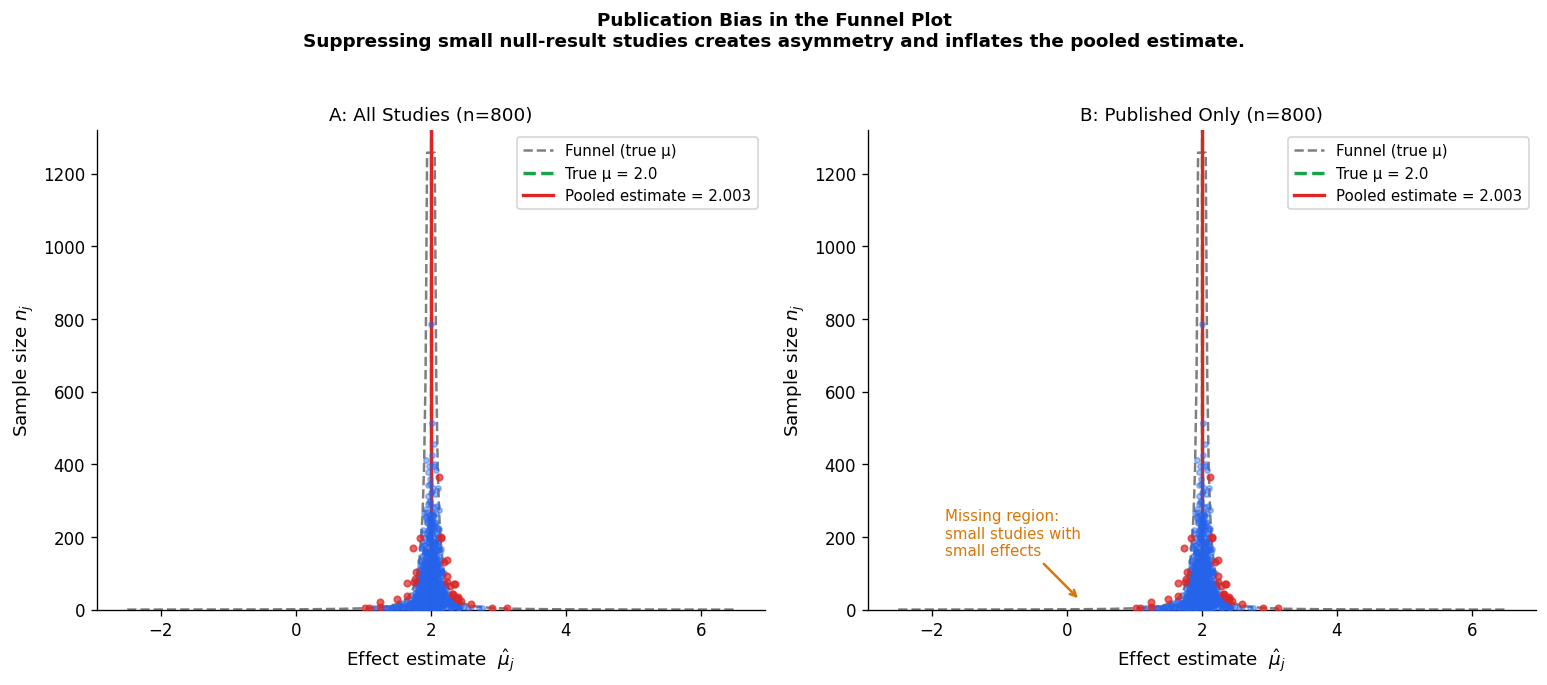

✓ Saved: figures/05_publication_bias.png

True μ:                        2.000
Pooled estimate (all studies): 2.003  (error = +0.003)
Pooled estimate (published):   2.003  (error = +0.003)
Studies published: 800 / 800 = 100%


In [7]:
rng     = np.random.default_rng(99)
lam     = 80
J       = 800
mu_true = 2.0
alpha   = 0.05

n_all   = rng.exponential(scale=lam, size=J).astype(int).clip(min=5)
se_all  = 1.0 / np.sqrt(n_all)
mu_all  = rng.normal(loc=mu_true, scale=se_all)

# Publication bias: suppress small studies (n < 100) with effect below significance threshold
sig_threshold = stats.norm.ppf(1 - alpha/2) / np.sqrt(n_all)
published     = (n_all >= 100) | (mu_all > sig_threshold)

mu_pool_all, se_pool_all = meta_weighted(mu_all,            n_all)
mu_pool_pub, se_pool_pub = meta_weighted(mu_all[published], n_all[published])

b_range_plot = np.linspace(mu_true - 4.5, mu_true + 4.5, 400)
b_range_plot = b_range_plot[np.abs(b_range_plot - mu_true) > 0.05]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, mask, title, pool_est, pool_se in [
    (ax1, np.ones(J, dtype=bool), f'A: All Studies (n={J})',           mu_pool_all, se_pool_all),
    (ax2, published,              f'B: Published Only (n={published.sum()})', mu_pool_pub, se_pool_pub),
]:
    n_plot  = n_all[mask]
    mu_plot = mu_all[mask]

    # Colour by whether inside funnel around true mu
    inside_mask = np.abs(mu_plot - mu_true) < 2.0 / np.sqrt(n_plot)
    ax.scatter(mu_plot[inside_mask],  n_plot[inside_mask],  color=BLUE, s=10, alpha=0.4, zorder=3)
    ax.scatter(mu_plot[~inside_mask], n_plot[~inside_mask], color=RED,  s=15, alpha=0.7, zorder=4)

    # Funnel boundary around true mu
    n_bound = funnel_boundary_n(b_range_plot, mu_true)
    ax.plot(b_range_plot, n_bound, 'k--', lw=1.5, alpha=0.5, label='Funnel (true μ)')

    ax.axvline(mu_true,   color=GREEN,  lw=2, ls='--', label=f'True μ = {mu_true}')
    ax.axvline(pool_est,  color=RED,    lw=2, ls='-',
               label=f'Pooled estimate = {pool_est:.3f}')

    ax.set_xlabel('Effect estimate  $\\hat{\\mu}_j$')
    ax.set_ylabel('Sample size $n_j$')
    ax.set_ylim(bottom=0)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)

    if title.startswith('B'):
        ax.annotate(
            'Missing region:\nsmall studies with\nsmall effects',
            xy=(mu_true - 1.8, 25), xytext=(mu_true - 3.8, 150),
            arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1.5),
            fontsize=9, color=ORANGE
        )

plt.suptitle(
    'Publication Bias in the Funnel Plot\n'
    'Suppressing small null-result studies creates asymmetry and inflates the pooled estimate.',
    fontsize=11, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.savefig('figures/05_publication_bias.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/05_publication_bias.png')
print(f'\nTrue μ:                        {mu_true:.3f}')
print(f'Pooled estimate (all studies): {mu_pool_all:.3f}  (error = {mu_pool_all - mu_true:+.3f})')
print(f'Pooled estimate (published):   {mu_pool_pub:.3f}  (error = {mu_pool_pub - mu_true:+.3f})')
print(f'Studies published: {published.sum()} / {J} = {published.mean():.0%}')

<a id='7'></a>
## 7. Egger's Test — Formal Asymmetry Test

**Egger's test** (Egger et al., 1997) is a formal regression-based test for funnel plot asymmetry. Under no publication bias, the standardized effect size $\hat{\mu}_j / \text{SE}_j$ should not be correlated with precision $1/\text{SE}_j$. The test regresses:

$$\frac{\hat{\mu}_j}{\text{SE}_j} = a + b \cdot \frac{1}{\text{SE}_j} + \varepsilon_j$$

- Under symmetry: intercept $a = 0$ (the line passes through the origin)
- Under publication bias: $a \neq 0$ — the funnel is tilted

The test is a standard $t$-test on the intercept $\hat{a}$.

=== Egger's Test Results ===
                                 Intercept    t-stat     p-value            Conclusion
All studies (no bias)               -0.107     -1.36      0.1752           Symmetric ✓
Published only (biased)             -0.107     -1.36      0.1752           Symmetric ✓


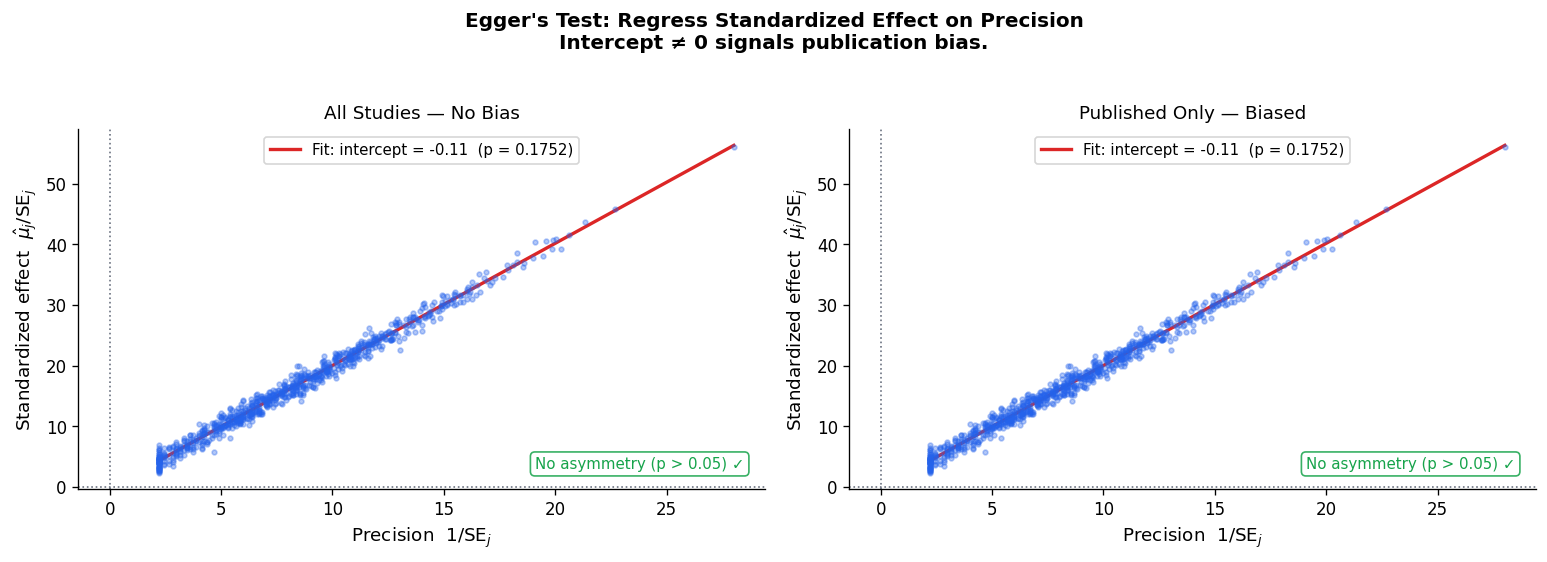

✓ Saved: figures/06_eggers_test.png


In [8]:
def eggers_test(mu_hats, ses):
    """Egger's test for funnel plot asymmetry.
    Regresses standardized effect on precision; tests if intercept = 0.
    Returns (intercept, slope, t_stat, p_value).
    """
    precision = 1.0 / ses
    std_effect = mu_hats / ses
    slope, intercept, r, p, se = stats.linregress(precision, std_effect)
    # t-stat for intercept (Egger tests the intercept, not the slope)
    n  = len(mu_hats)
    # Refit with statsmodels-style: use OLS residuals for intercept SE
    X  = np.column_stack([np.ones(n), precision])
    y  = std_effect
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    resid = y - X @ beta
    s2 = resid.var(ddof=2)
    cov = s2 * np.linalg.inv(X.T @ X)
    se_intercept = np.sqrt(cov[0, 0])
    t_intercept  = beta[0] / se_intercept
    p_intercept  = 2 * stats.t.sf(abs(t_intercept), df=n-2)
    return beta[0], beta[1], t_intercept, p_intercept

# Apply Egger's test to both scenarios from Section 6
se_all_arr = 1.0 / np.sqrt(n_all)
se_pub_arr = 1.0 / np.sqrt(n_all[published])

a_all, b_all, t_all, p_all = eggers_test(mu_all,            se_all_arr)
a_pub, b_pub, t_pub, p_pub = eggers_test(mu_all[published], se_pub_arr)

print('=== Egger\'s Test Results ===')
print(f'{"":30s}  {"Intercept":>10}  {"t-stat":>8}  {"p-value":>10}  {"Conclusion":>20}')
print(f'{"All studies (no bias)":<30}  {a_all:>10.3f}  {t_all:>8.2f}  {p_all:>10.4f}  '
      f'{"Symmetric ✓" if p_all > 0.05 else "Asymmetric ✗":>20}')
print(f'{"Published only (biased)":<30}  {a_pub:>10.3f}  {t_pub:>8.2f}  {p_pub:>10.4f}  '
      f'{"Symmetric ✓" if p_pub > 0.05 else "Asymmetric ✗":>20}')

# Visualize: standardized effect vs precision for both scenarios
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, mu_arr, se_arr, a, b, t, p, title in [
    (ax1, mu_all,            se_all_arr, a_all, b_all, t_all, p_all, 'All Studies — No Bias'),
    (ax2, mu_all[published], se_pub_arr, a_pub, b_pub, t_pub, p_pub, 'Published Only — Biased'),
]:
    prec     = 1.0 / se_arr
    std_eff  = mu_arr / se_arr
    ax.scatter(prec, std_eff, color=BLUE, s=8, alpha=0.35, zorder=3)

    x_line = np.linspace(prec.min(), prec.max(), 200)
    ax.plot(x_line, a + b * x_line, color=RED, lw=2,
            label=f'Fit: intercept = {a:.2f}  (p = {p:.4f})')
    ax.axhline(0, color=GRAY, ls=':', lw=1)
    ax.axvline(0, color=GRAY, ls=':', lw=1)

    verdict    = 'No asymmetry (p > 0.05) ✓' if p > 0.05 else 'Asymmetry detected (p < 0.05) ✗'
    box_color  = GREEN if p > 0.05 else RED
    ax.text(0.97, 0.05, verdict,
            transform=ax.transAxes, ha='right', va='bottom', fontsize=9, color=box_color,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=box_color, alpha=0.85))

    ax.set_xlabel('Precision  $1/\\text{SE}_j$')
    ax.set_ylabel('Standardized effect  $\\hat{\\mu}_j / \\text{SE}_j$')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle(
    "Egger's Test: Regress Standardized Effect on Precision\n"
    'Intercept ≠ 0 signals publication bias.',
    fontsize=12, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.savefig('figures/06_eggers_test.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/06_eggers_test.png')

<a id='8'></a>
## 8. Summary & Corollaries

All results follow directly from the inverse-variance weighting framework and the simple model for study sizes.

In [9]:
corollaries = pd.DataFrame([
    {
        'Concept': 'Simple average',
        'Formula': 'μ̂ = (1/J) Σ μ̂_j',
        'Problem': 'Gives equal weight to n=10 and n=10,000',
        'When to use': 'Never — use weighted average instead'
    },
    {
        'Concept': 'Inverse-variance weighted average',
        'Formula': 'μ̂ = Σ(μ̂_j · n_j/σ²_j) / Σ(n_j/σ²_j)',
        'Problem': 'Requires knowing (or estimating) σ_j',
        'When to use': 'Standard meta-analysis — minimum-variance linear estimator'
    },
    {
        'Concept': 'Simple model (σ_j=1, n~Exp)',
        'Formula': 'μ̂_j ~ N(μ, 1/n_j),  log(n/λ) ~ Unif(0,1)',
        'Problem': 'Assumes homogeneous variance across studies',
        'When to use': 'Theoretical analysis of funnel plot shape'
    },
    {
        'Concept': 'Funnel plot boundary',
        'Formula': 'b = μ ± 2/√n  →  n = (2/|b−μ|)²',
        'Problem': 'Visual inspection is subjective',
        'When to use': 'First diagnostic for publication bias'
    },
    {
        'Concept': 'Publication bias',
        'Formula': 'Missing lower-left of funnel',
        'Problem': 'Inflates pooled estimate; literature unrepresentative',
        'When to use': 'Diagnose with funnel plot + Egger\'s test'
    },
    {
        'Concept': "Egger's test",
        'Formula': 'μ̂_j/SE_j = a + b·(1/SE_j) + ε,  test a=0',
        'Problem': 'Low power when J is small',
        'When to use': 'Formal test of funnel asymmetry; p < 0.05 suggests bias'
    },
])

pd.set_option('display.max_colwidth', 60)
pd.set_option('display.width', 200)
corollaries.set_index('Concept')

,Formula,Problem,When to use
Concept,,,
Simple average,μ̂ = (1/J) Σ μ̂_j,"Gives equal weight to n=10 and n=10,000",Never — use weighted average instead
Inverse-variance weighted average,μ̂ = Σ(μ̂_j · n_j/σ²_j) / Σ(n_j/σ²_j),Requires knowing (or estimating) σ_j,Standard meta-analysis — minimum-variance linear estimator
"Simple model (σ_j=1, n~Exp)","μ̂_j ~ N(μ, 1/n_j), log(n/λ) ~ Unif(0,1)",Assumes homogeneous variance across studies,Theoretical analysis of funnel plot shape
Funnel plot boundary,b = μ ± 2/√n → n = (2/|b−μ|)²,Visual inspection is subjective,First diagnostic for publication bias
Publication bias,Missing lower-left of funnel,Inflates pooled estimate; literature unrepresentative,Diagnose with funnel plot + Egger's test
Egger's test,"μ̂_j/SE_j = a + b·(1/SE_j) + ε, test a=0",Low power when J is small,Formal test of funnel asymmetry; p < 0.05 suggests bias


---

## 📝 Key Takeaways

| Concept | What to Remember |
|---------|------------------|
| **Simple average** | Treats all studies equally — wrong when study sizes vary |
| **Inverse-variance weights** | $w_j = n_j/\hat{\sigma}_j^2$ — larger studies get more weight; this is the BLUE |
| **Simple model** | $\hat{\mu}_j \sim N(\mu, 1/n_j)$,  $n \sim \text{Exp}(\lambda)$ — log-uniform sample sizes |
| **Funnel boundary** | $b = \mu \pm 2/\sqrt{n}$ — inverts to $n = (2/|b-\mu|)^2$ — gives funnel shape |
| **Funnel plot** | $\hat{\mu}_j$ (horizontal) vs $n_j$ (vertical) — symmetric under no bias |
| **Publication bias** | Small null-result studies missing → lower-left region empty → asymmetric funnel |
| **Bias on the estimate** | Publication bias pulls the pooled estimate away from the true $\mu$ |
| **Egger's test** | Regress $\hat{\mu}_j/\text{SE}_j$ on $1/\text{SE}_j$; intercept $\neq 0$ → asymmetry → bias |

---

## 📚 References

- Schwartzman, A. (2026). *DSC 215 Lecture Slides: Meta-Analysis and Publication Bias.* UCSD.
- Egger, M., Davey Smith, G., Schneider, M., & Minder, C. (1997). *Bias in meta-analysis detected by a simple, graphical test.* BMJ 315: 629–634.
- Borenstein, M., Hedges, L.V., Higgins, J.P.T., & Rothstein, H.R. (2009). *Introduction to Meta-Analysis.* Wiley.

---
*DSC 215 · UCSD · Spring 2026 · Prof. Armin Schwartzman*